Contenido bajo licencia Creative Commons BY 4.0 y código bajo licencia MIT. © Nicolás Guarín-Zapata 2026.

# Elementos finitos en 1D

Queremos resolver al ecuación de Poisson en 1D usando
el método de elementos finitos.

$$-\frac{d^2 u}{dx^2} = f(x)\, ,$$

con $u(0) = u(1)  = 0$.

Vamos a usar una solución aproximada de la forma

$$u(x) = \sum_{n=0}^{N} u_n \phi_n(x)\, ,$$

Si usamos el método de Galerkin, la ecuación diferencial es equivalente
al siguiente problema

$$\int_{0}^{1} \frac{d u}{d x} \frac{d \phi_n}{d x} dx
= \int_{0}^{1}  \phi_n f(x) dx\, \quad \forall \phi_n\, .$$

Si remplazamos $u(x)$ en este sistema obtenemos

$$\sum_{j=0}^N \left[\int_{0}^{1} \frac{d \phi_i}{d x} \frac{d \phi_j}{d x} dx\right] u_j
= \int_{0}^{1}  \phi_j f(x) dx\, \quad \forall \phi_j\, .$$

Esto lleva al siguiente sistema de ecuaciones

$$[K]\{\mathbf{u}\} = \{\mathbf{b}\}$$

donde la matriz de rigidez global está dada por

$$[K] =  \frac{1}{h}\begin{bmatrix}
1 &-1 &0 &\cdots &\cdots &0\\
-1 &2 &-1 & & &0\\
0 &-1 &2 & & &0\\
\vdots & & &\ddots & &\vdots\\
\vdots & & & &2 &-1\\
0 &\cdots &\cdots &\cdots &-1 &1\\\end{bmatrix}$$

y el vector de cargas es

$$b_\text{local} = \frac{h}{4}\begin{bmatrix}
f(x_0) + f(x_1)\\
f(x_0) + 2f(x_1) + f(x_2)\\
f(x_1) + 2f(x_2) + f(x_3)\\
\vdots\\
f(x_{N - 2}) + 2f(x_{N - 1}) + f(x_{N})\\
f(x_{N - 1}) + f(x_N)
\end{bmatrix}\, ,$$

donde $h$ es el tamaño del elemento. Acá estamos asumiendo que el término fuente
es constante sobre cada elemento, es decir, que para el elemento
entre los nodos $i$ e $i + 1$ toma el valor

$$\frac{f_{i} + f_{i + 1}}{2}\, $$


<div class="alert alert-info">

Demuestre que la integral para el término fuente da la expresión
mostrada anteriormente.

</div>

In [1]:
if 'google.colab' in str(get_ipython()):
    %pip install ipympl
    from google.colab import output
    output.enable_custom_widget_manager()

In [2]:
%matplotlib widget

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import *

In [4]:
init_printing()

# Configuracion graficos
gris = '#757575'
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["text.color"] = gris
plt.rcParams["font.size"] = 12
plt.rcParams["xtick.color"] = gris
plt.rcParams["ytick.color"] = gris
plt.rcParams["axes.labelcolor"] = gris
plt.rcParams["axes.edgecolor"] = gris
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False

In [5]:
def global_mats(coords, source):
    h = coords[1] - coords[0]
    N = len(coords)
    stiff = np.diag(np.full(N, 2), 0)\
        + np.diag(np.full(N-1, -1), -1)\
        + np.diag(np.full(N-1, -1), 1)
    stiff[0, 0] = stiff[-1, -1] = 1
    rhs = np.zeros((N))
    f = source(coords)
    for cont in range(N):
        if cont == 0:
            rhs[0] = f[0] + f[1]
        if cont == N - 1:
            rhs[-1] = f[-2] + f[-1]
        else:
            rhs[cont] = f[cont - 1] + 2*f[cont] + f[cont + 1]
    return stiff/h, 0.25 * h * rhs

Probemos la implementación con la función $f(x) = 20 x^3$, que lleva a
la solución

$$u(x) = - x (x^4 - 1)$$

In [6]:
N = 21
N_eval = 200
fun = lambda x: 20*x**3
x = np.linspace(0, 1, N)
x_eval = np.linspace(0, 1, N_eval)

Podemo usar ``global_mats`` para obtener la matriz de rigidez y el vector de cargas.

In [7]:
stiff, rhs = global_mats(x, fun)

Y esta matriz y vector podemos usarla para resolver el sistema de ecuaciones
resultante con ``np.linalg.solve``.

En este caso no tomamos la matriz completa sino que dejamos por
fuera las filas/columnas correspondientes al primer y último
grado de libertad ya que tenemos condiciones de Dirichlet homogéneas.

In [8]:
sol = np.zeros(N)
sol[1:-1] = np.linalg.solve(stiff[1:-1, 1:-1], rhs[1:-1])

Podemos comparar la solución numérica con la solución analítica.

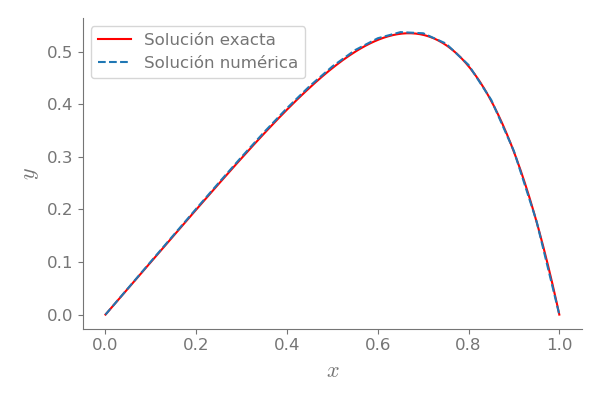

In [9]:
plt.figure(figsize=(6, 4))
plt.plot(x_eval, -x_eval*(x_eval**4 - 1), color="red")
plt.plot(x, sol, linestyle="dashed")
plt.xlabel(r"$x$", fontsize=16)
plt.ylabel(r"$y$", fontsize=16)
plt.legend(["Solución exacta", "Solución numérica"])
plt.tight_layout()
plt.show()

<div class="alert alert-info">

Pruebe a cambiar el número de nodos usados o el término fuente.

</div>